In [1]:
import os
import numpy as np
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset , DataLoader , random_split
import matplotlib.pyplot as plt
from tqdm import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

import sys
sys.path.append("..")
from utils.Unet import Unet

import torch
import torch.nn as nn
import torch.optim as optim

In [21]:
dataset_path = "../dataset/oxford-iiit-pet"
model_save_path = "../models/model.pth"

images_path = os.path.join(dataset_path, "images")
masks_path = os.path.join(dataset_path, "annotations/trimaps")

In [3]:
image_transfom = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.PILToTensor()
])

In [4]:
class PetDataset(Dataset):

    def __init__(self, images_path, masks_path, transform=None):
        
        self.images_path = images_path
        self.masks_path = masks_path
        self.transform = transform

        self.images = [f for f in os.listdir(images_path) if f.endswith(".jpg")]        

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.images_path, img_name)

        mask_name = img_name.replace(".jpg", ".png")
        mask_path = os.path.join(self.masks_path, mask_name)

        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path))

        mask = (mask != 2).astype("float32")

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"].float().unsqueeze(0)

        return image, mask

In [5]:
train_transform = A.Compose([
    A.Resize(128, 128),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20 , p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2()
])

In [6]:
dataset = PetDataset(
    images_path,
    masks_path,
    transform=train_transform
)

In [7]:
image, mask = dataset[0]

print(image.shape)
print(mask.shape)

torch.Size([3, 128, 128])
torch.Size([1, 128, 128])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.012549].


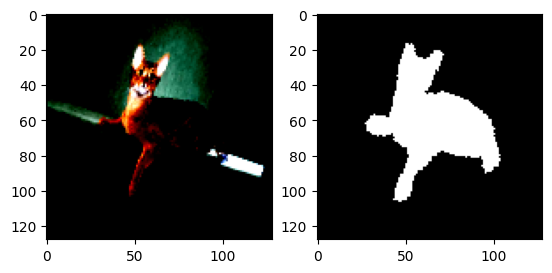

In [8]:
plt.subplot(1,2,1)
plt.imshow(image.permute(1,2,0))

plt.subplot(1,2,2)
plt.imshow(mask.squeeze(), cmap="gray")

plt.show()

In [9]:
print("Torch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA Available: True
GPU: NVIDIA GeForce RTX 2050


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [11]:
train_size = int(0.8*len(dataset))
val_size = len(dataset) - train_size

train_dataset , val_dataset = random_split(dataset , [train_size , val_size])

In [12]:
model = Unet().to(device)

In [13]:
criterion = nn.BCEWithLogitsLoss()

In [14]:
optimizer = optim.Adam(model.parameters() , lr = 1e-4)

In [15]:
train_loader= DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

In [ ]:
print("Total samples:", len(dataset))
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Total samples: 7390
Train samples: 5912
Validation samples: 1478


In [17]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

torch.Size([4, 3, 128, 128])
torch.Size([4, 1, 128, 128])


In [18]:
model.train()
images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.float().to(device)

preds = model(images)
loss = criterion(preds, masks)
optimizer.zero_grad()
loss.backward()

for name, param in model.named_parameters():
    if param.grad is not None:
        print(f"{name}: {param.grad.abs().mean():.8f}")

down1.conv.0.weight: 0.00527620
down1.conv.1.weight: 0.00237971
down1.conv.1.bias: 0.00216254
down1.conv.3.weight: 0.00379240
down1.conv.4.weight: 0.00167262
down1.conv.4.bias: 0.00174691
down2.conv.0.weight: 0.00050127
down2.conv.1.weight: 0.00025998
down2.conv.1.bias: 0.00022054
down2.conv.3.weight: 0.00040624
down2.conv.4.weight: 0.00021934
down2.conv.4.bias: 0.00018542
down3.conv.0.weight: 0.00005815
down3.conv.1.weight: 0.00002874
down3.conv.1.bias: 0.00002737
down3.conv.3.weight: 0.00005117
down3.conv.4.weight: 0.00002836
down3.conv.4.bias: 0.00002368
bottleneck.conv.0.weight: 0.00001186
bottleneck.conv.1.weight: 0.00000617
bottleneck.conv.1.bias: 0.00000532
bottleneck.conv.3.weight: 0.00001007
bottleneck.conv.4.weight: 0.00000608
bottleneck.conv.4.bias: 0.00000577
up1.weight: 0.00000978
up1.bias: 0.00000855
conv1.conv.0.weight: 0.00004009
conv1.conv.1.weight: 0.00002424
conv1.conv.1.bias: 0.00002027
conv1.conv.3.weight: 0.00003951
conv1.conv.4.weight: 0.00002494
conv1.conv.4.bia

In [19]:
print(model)

Unet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_st

In [22]:
num_epochs = 10
best_val_loss = float('inf')

for epoch in range(num_epochs):
    # ── Training ──────────────────────────────────────────
    model.train()
    train_loss = 0

    train_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train", leave=False)
    for images, masks in train_bar:
        images = images.to(device)
        masks = masks.float().to(device)

        preds = model(images)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")  # live loss per batch

    train_loss /= len(train_loader)

    # ── Validation ────────────────────────────────────────
    model.eval()
    val_loss = 0
    val_iou = 0

    val_bar = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Val  ", leave=False)
    with torch.no_grad():
        for images, masks in val_bar:
            images = images.to(device)
            masks = masks.float().to(device)

            preds = model(images)
            loss = criterion(preds, masks)
            val_loss += loss.item()

            preds_binary = (torch.sigmoid(preds) > 0.5).float()
            intersection = (preds_binary * masks).sum()
            union = preds_binary.sum() + masks.sum() - intersection
            val_iou += (intersection + 1e-6) / (union + 1e-6)

            val_bar.set_postfix(loss=f"{loss.item():.4f}")  # live loss per batch

    val_loss /= len(val_loader)
    val_iou /= len(val_loader)

    # ── Summary ───────────────────────────────────────────
    print(f"Epoch [{epoch+1}/{num_epochs}]  "
          f"Train Loss: {train_loss:.4f}  |  "
          f"Val Loss: {val_loss:.4f}  |  "
          f"Val IoU: {val_iou:.4f}")

    # ── Save best model ───────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), model_save_path)
        print(f"  ✅ Best model saved (val_loss: {val_loss:.4f})")

Epoch [1/10]  Train Loss: 0.2828  |  Val Loss: 0.2746  |  Val IoU: 0.7721
  ✅ Best model saved (val_loss: 0.2746)


Epoch [2/10]  Train Loss: 0.2521  |  Val Loss: 0.2351  |  Val IoU: 0.7908
  ✅ Best model saved (val_loss: 0.2351)


Epoch [3/10]  Train Loss: 0.2339  |  Val Loss: 0.2267  |  Val IoU: 0.7918
  ✅ Best model saved (val_loss: 0.2267)


Epoch [4/10]  Train Loss: 0.2213  |  Val Loss: 0.2279  |  Val IoU: 0.7880


Epoch [5/10]  Train Loss: 0.2086  |  Val Loss: 0.2024  |  Val IoU: 0.8167
  ✅ Best model saved (val_loss: 0.2024)


Epoch [6/10]  Train Loss: 0.2018  |  Val Loss: 0.2099  |  Val IoU: 0.8056


Epoch [7/10]  Train Loss: 0.1931  |  Val Loss: 0.1904  |  Val IoU: 0.8257
  ✅ Best model saved (val_loss: 0.1904)


Epoch [8/10]  Train Loss: 0.1844  |  Val Loss: 0.1942  |  Val IoU: 0.8275


Epoch [9/10]  Train Loss: 0.1809  |  Val Loss: 0.1790  |  Val IoU: 0.8389
  ✅ Best model saved (val_loss: 0.1790)


Epoch [10/10]  Train Loss: 0.1759  |  Val Loss: 0.1820  |  Val IoU: 0.8385


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8606441..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2914162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.6399999].


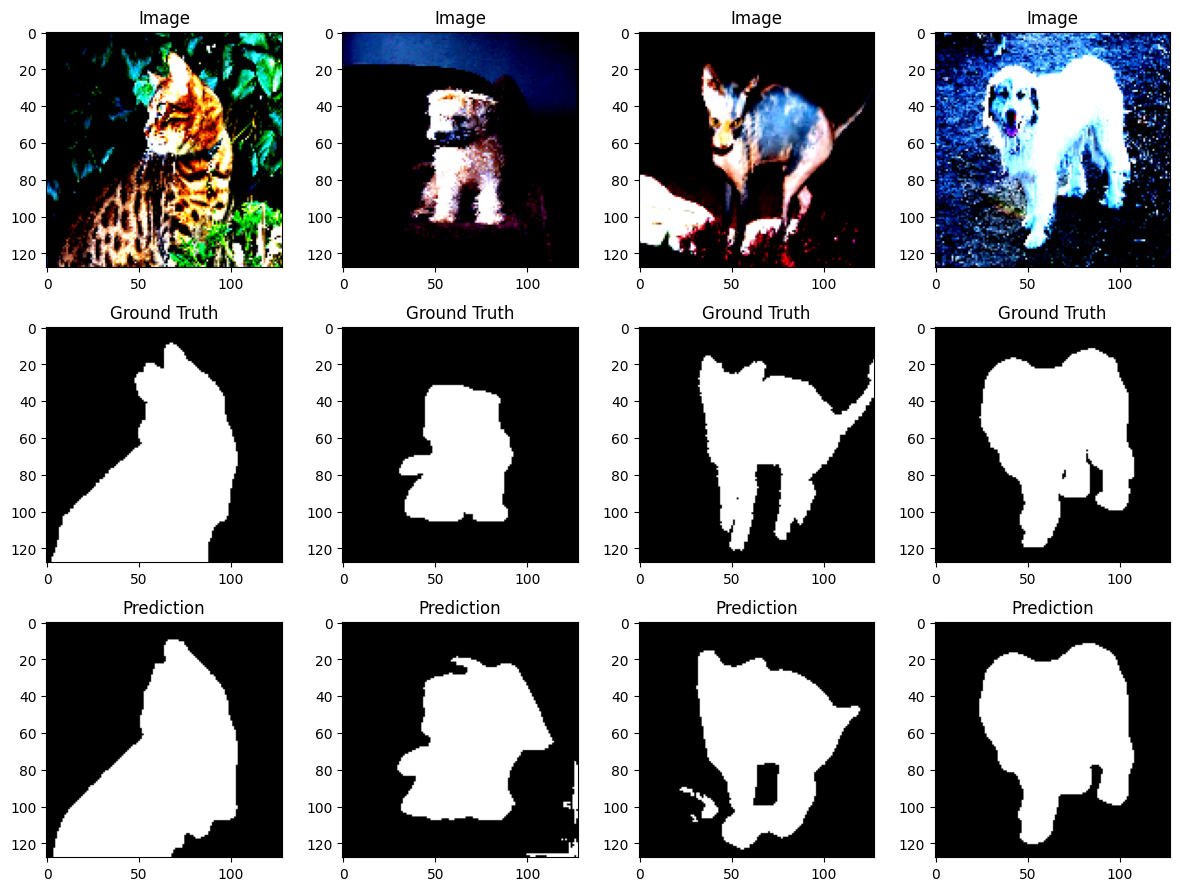

In [24]:
model.eval()
images, masks = next(iter(val_loader))
with torch.no_grad():
    preds = torch.sigmoid(model(images.to(device)))
    preds = (preds > 0.5).float()

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i in range(4):
    axes[0, i].imshow(images[i].permute(1, 2, 0))
    axes[0, i].set_title("Image")
    axes[1, i].imshow(masks[i].squeeze(), cmap="gray")
    axes[1, i].set_title("Ground Truth")
    axes[2, i].imshow(preds[i].cpu().squeeze(), cmap="gray")
    axes[2, i].set_title("Prediction")
plt.tight_layout()
plt.savefig("../output/predictions.png")